# Logistic Regression

In this lab, we will look at one of the most simple classification algorithms, namely Logistic Regression.  We look at how we can motivate classification from the linear regression setting, formulate the problem as a Maximum Likelihood Estimation.  We then learn how to use sklearn for Logistic Regression and see how it works on both real and synthetic data. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

## From Linear Regression to Logistic Regression

Consider a simple one-dimensional example to predict value of $y$ based on feature $x$, where $y \in \{-1,+1\}$, and $x \in \mathbb{R}$.

In [2]:
data = pd.read_csv("data_log_reg.csv")
X = pd.DataFrame(data.x)
y = pd.DataFrame(data.y)
X.head()

,x
0,-2.000000
1,-1.890089
2,-1.801019
3,-1.622105
4,-1.278516


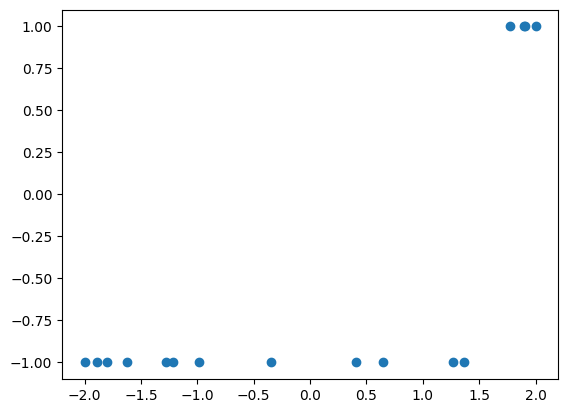

In [3]:
plt.scatter(X,y)

In [4]:
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
log_reg.fit(X, y)


print(log_reg.predict(pd.DataFrame([1.4])))
print(log_reg.predict(pd.DataFrame([1.6])))

[-1]
[1]


/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


We see that the model does what you expect it to do and predicts the class 1 if we are past a given threshold. Let's try to understand in better detail what the model does mathematically.

For a start, let's naively try a linear regression on the data points above.

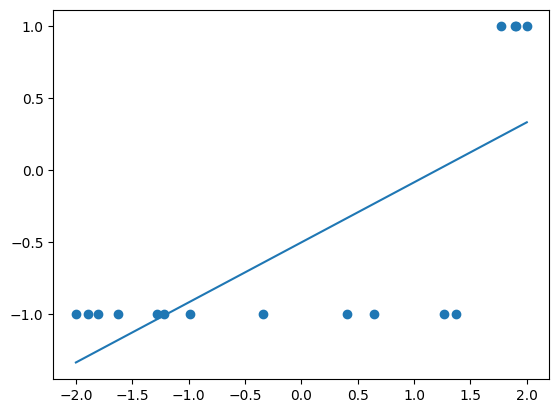

In [5]:
linear_reg = LinearRegression()
linear_reg.fit(X,y)  #fitting the model

w = linear_reg.coef_[0] #extracting the coefficients
b = linear_reg.intercept_

xs = np.array([-2,2]) #plotting the regression line (since it is alinear map from one D space to 1d space, two points are enough to plot it)
ys = w*xs + b 
plt.plot(xs, ys)#plotting the line

plt.scatter(X,y) #plotting the observations

First, notice that it does not fit well.  Secondly, and more importantly, the predicted values are continuous over all possible values, i.e. any value is possible.  This is not helpful the classes are either $-1$ or $1$.  This is where the logistic function comes into place. Instead of using a purely linear model, logistic regression uses a linear function to compute a "score" with the following property: the higher the score, the more "likely" it is that the datapoint is in class $1$. For this, we need to feed the score into a function which maps the real numbers to the interval $[0,1]$, so that we can loosely interpret the result as a probability. In fact, we will show that the entire algorithm can be interpreted as an instance of maximum likelihood estimation.

The function we choose is the so-called "logistic function", and maps any real value to one which is in range $(0,1)$.  This is how it looks like:

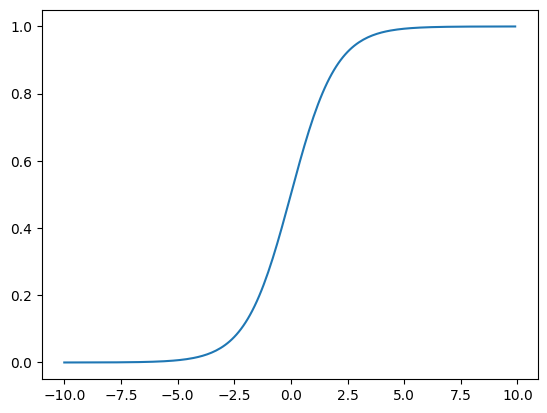

In [6]:
xs = np.arange(-10,10,0.1)  #setting a mesh of points to draw a plot
ys = 1/(1+np.exp(-1.*xs))  #computing the sigmoid at each of the points
plt.plot(xs, ys) #making the plot

## Formulating Logistic Regression

In other words, in Logistic Regression we are interested in finding an estimate $Pr(y=1|x)$ for each $x$ (both in the training set or outside it).  In one-dimension, it takes the form

$$
Pr(y=1 | x) = \frac{1}{1+e^{-(wx+b)}} \tag{1}
$$

$$
Pr(y=-1 | x) = \frac{1}{1+e^{(wx+b)}} \tag{2}
$$

where $w$ and $b$ are values we will estimate via our training data.

Say we have the following three samples

$$
x_1 = 0.8, y_1=1 \\
x_2 = -1.0, y_2=-1 \\
x_3 = 1.2, y_3=1
$$

What is the probability you get the $y$ given $x$ assuming the data actually was generated by a logistic model with a fixed value of the parameters?  This is called the likelihood and in the i.i.d. general case case is given by

$$
\mathscr{L} = Pr(y=1|x_1=0.8) \times Pr(y=-1|x_2=-1) \times Pr(y=1|x_3=1.2)
$$

Assuming the functional form (1), we then can express likelihood

$$
\mathscr{L} = \frac{1}{1+e^{-(0.8w+b)}} \frac{1}{1+e^{(-w+b)}} \frac{1}{1+e^{-(1.2w+b)}} \tag{3}
$$

Note here in the second term we have to calculate $Pr(y=-1|x)$ and this is given by

$$
Pr(y=-1 | x) = 1 -\frac{1}{1+e^{-(wx+b)}} = \frac{e^{-(wx+b)}}{1+e^{-(wx+b)}} = \frac{1}{1+e^{(wx+b)}}
$$

Taking the log of (3), we have 

$$
\ln \mathscr{L} = \ln \frac{1}{1+e^{-(0.8w+b)}} + \ln \frac{1}{1+e^{(-w+b)}} + \ln \frac{1}{1+e^{-(1.2w+b)}}
$$

Our objective is to find the values of $w$ and $b$ that give rise to the maximum log-likelihood,  $\ln \mathscr{L}$.  Or equivalently we want to solve the following minimization problem

$$
\min_{w,b} \ln (1+e^{-(0.8w+b)}) +\ln (1+e^{(-w+b)}) + \ln (1+e^{-(1.2w+b)}) 
$$

There is no exact solution to this problem :).  However as it is a convex function, one can solve it numerically using Gradient Descent or other improved similar algorithms. <br>

To generalize and summarize, in Logistic Regression, what we want is to find is the probability of a class, either $+1$ or $-1$ given the feature vector $\vec{x}$, i.e.

$$
Pr(y|\vec{x}) = \frac{1}{1+e^{-y(\vec{w}^\top \vec{x})}}
$$

To find the maximum likelihood estimator $\vec{w}$, we solve the following

$$
\min_{\vec{w}} \sum_{i=1}^{n} \ln ( 1+\exp  ( -y_i\vec{w}^\top \vec{x_i} ))
$$

Below, we run the logistic regression model on the same data as above and show the results. 

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


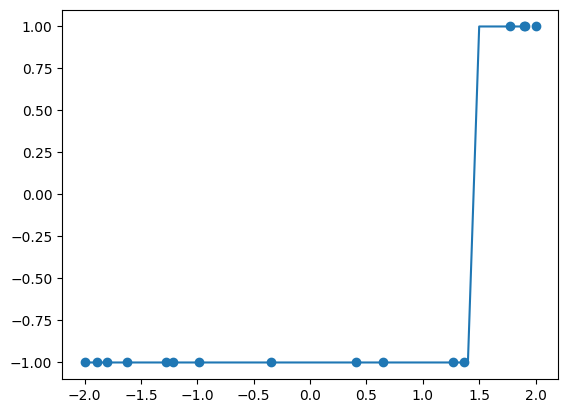

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



data = pd.read_csv("data_log_reg.csv")

X = data[["x"]]
y = data.y

plt.scatter(X,y)  #adding the raw observations to the plot object
log_reg = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000) #deploying sklearn magic...
# multinomial ensures that the multiclass formulation uses the multivariate cross entropy loss introduced in class, 
#the solver lbfgs stands for Limited-memory Broyden–Fletcher–Goldfarb–Shanno, it's complicated gradient based algorithm 
# which incorporates second order information. the solver "saga" is closer to SGD and will work better on larger datasets
# max_iter is the maximum number of iterations
log_reg.fit(X,y)  #fitting the model so that my class instance now has attributes corresponding to the parameters of the model

xs = np.arange(-2,2,0.1)
ys=log_reg.predict(xs.reshape(-1,1)) #remember that the predict method only works with 2 dimensional arrays as input
plt.plot(xs,ys)



### Using sklearn for Logistic Regression on the Iris dataset

We use the iris dataset to demonstrate the use of sklearn.  Note however in this case we have a multi-class classification problem (we are not going into the mathematical details of how this works here), but this is very similar to the one class case. 

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression, LogisticRegression

data = pd.read_csv("iris.csv")

X = data.drop(columns=["variety"])
y = data.variety

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


log_reg = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000)  #define model (class instance)
log_reg.fit(X_train, y_train) #fit model

y_pred = log_reg.predict(X_test) #make predictions. Here we have multi dimensional inputs already
#so there is no need  for any .reshape(-1,1) nonesense


from sklearn.metrics import accuracy_score
round(accuracy_score(y_pred, y_test), 5)

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


0.96667

In [9]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
lr_probs = log_reg.predict_proba(X_test)
# keep probabilities for the positive outcome only
# lr_probs = lr_probs[:, 1]
# calculate scores
lr_auc = roc_auc_score(y_test, lr_probs,multi_class="ovr")
print(lr_auc)

1.0


Let's try some synthetic data to better understand how all this works at depth in the one dimensional, binary classification case. 

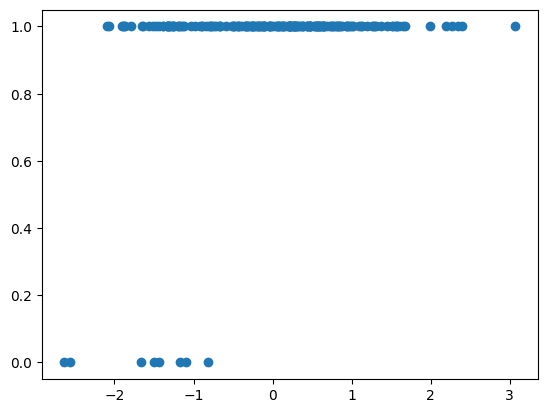

In [10]:
xs=np.arange(-2,2,0.001)
n_samples=200
x=np.random.randn(n_samples)

multi=1

# w_gt=multi*np.array([16,8])   #it's easier to change one factor like this (w_gt are the final weights)
w_gt=multi*np.array([5,2])
scores_gt=w_gt[1]*x+w_gt[0]  #computing scores as a linear function of my input
sig= lambda u:  1/(1+np.exp(-1.*u))  #sigmoid function


y=np.random.binomial(1,sig(scores_gt))  #generating bernouilli variables with probabilities given by sig(scores_gt). 
#np.random.binomial(1,p) gives a random variable which takes value 1 with probability p and value 0 otherwise. 



plt.scatter(x,y)




So the above data was actually generated by a logistic model. Let's try to actually run logistic regression on it to see how it works.

testaccuracy: 0.97
0.970000000000000


/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


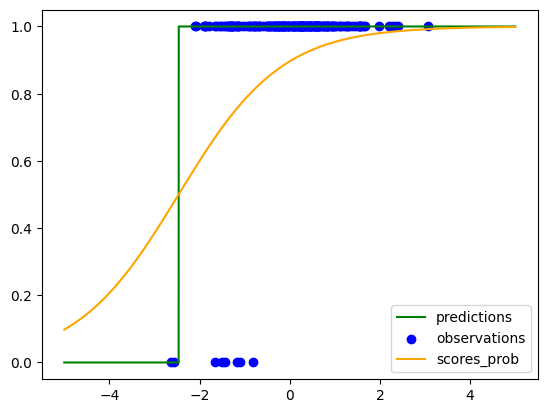

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
log_reg = LogisticRegression(solver='lbfgs', multi_class='multinomial', max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42)  #don't train on the test set!!!!
log_reg.fit(X_train.reshape(-1,1), y_train)

y_pred = log_reg.predict(X_test.reshape(-1,1)) #we have one dimensional input data so we need to reshape

print(f"testaccuracy: {round(accuracy_score(y_pred, y_test), 5)}")

xs = np.arange(-5,5,0.001) #planning to plot the sigmoid of the scores (predicted probabilities)
#as well as the actual predictions, setting up the mesh on the x axis
ys=log_reg.predict(xs.reshape(-1,1))
plt.plot(xs,ys,label="predictions",color="green")
plt.scatter(x,y,label="observations",color="blue")



w=log_reg.coef_  #important: this is how you recover coefficients in logistic regression (strangely similar to the linear regression case...)
inter=log_reg.intercept_

zs=sig(w[0][0]*xs+inter[0])
plt.plot(xs,zs,color="orange",label="scores_prob")
# plt.ylim(bottom=-0.2,top=1.2)
plt.legend()

print("{:.15f}".format(accuracy_score(y_pred,y_test)))

When you set a large value for the intercept, what do you observe? The accuracy is 100 percent (in this case where we set $w=[5,2]$... does that mean the model is very good? 

Not really: we could get very good accuracy by just predicting class 1 for any observation in this case. To really learn something meaningful, the model might benefit from more negative samples...

In [12]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
lr_probs = log_reg.predict_proba(X_test.reshape(-1,1))
# print(lr_probs.shape)
# keep probabilities for the positive outcome only
A=np.array(y_test)
B=[1-A,A]
y_test_dummy=np.array(B).transpose()
# print(y_test.shape)
# lr_probs = lr_probs[:, 1]
# calculate scores
lr_auc = roc_auc_score(y_test_dummy, lr_probs,multi_class="ovr")
print(lr_auc)

0.90625


#### Exercise 1: 

Suppose that we have some data that was generated in the following way: each input x is drawn from a normal distribution $X\sim N(0,1)$. Then the score $s(x)=w_{gt}x+ b $ is computed, and the label $y$ is generated so that for a given x, $$\mathbb{P}(y=1|X=x)=\frac{1}{1+e^{-s(x)}}$$

Suppose I were to train a logistic regression model on this data (without regularisation), what would be the approximation error? 




Following the code above: 

(1) write a function that takes as input a number of samples $N$, the weight $w$ and the intercept $b$, then generates a training set containing 50 percent of the samples, trains a logistic regression model without regularisation on the data and outputs the test error.
(2) Plot the graph of the function as a function of N various values of $w,b$. 
(3) What do you observe? 



#### Solution

In [15]:
def testlog(N,w,b):
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score
    log_reg = LogisticRegression(solver='lbfgs',  multi_class='multinomial', max_iter=1000)
    x=np.random.randn(N) #Generating N samples from a standard normal
    sig= lambda u:  1/(1+np.exp(-1.*u)) #defining the sigmoid function again...
    scores_gt=w*x+b #computing the scores via a linear map 
    y=np.random.binomial(1,sig(scores_gt)) #outputting the classes as bernouilli distributions with probabilities given by 
    #sigmoids of the scores
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42) #don't train on the test set!!!
    # note that in this case we are not regularizing anything: we don't have any hyperparameters. Hence we don't need a separate
    # validation set
    log_reg.fit(X_train.reshape(-1,1),y_train) #fitting the model. We need to reshape the inputs because there is only one dimension. Grrrr
    y_pred = log_reg.predict(X_test.reshape(-1,1)) #same thing for predictions (remember the predict method takes 2d arrays as input only)
    return accuracy_score(y_pred,y_test)
    
    
    
    
# print(testlog(50,1,0.1))

def plotlog(w,b): 
    xs=list(range(100,1000,5))+list(range(1000,20000,500))+list(range(20000,100000,5000)) #for computational reasons, I am
    #plotting the graph with a different step size at different scales (otherwise it would not be computationally feasible to run everything in class)
    ys=[testlog(u,w,b) for u in xs] #calling my function testlog which generates the model and computes the accuracy
    plt.plot(xs,ys)
    plt.show()

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper bina

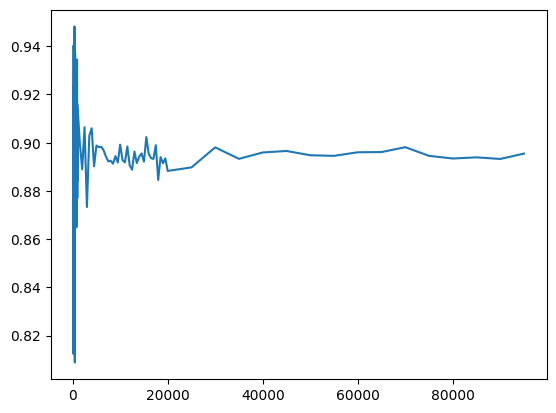

In [16]:
plotlog(5,0.1)

We observe that the test error oscillates but seems to converge as the number of samples increases. The larger the value of $w$, the larger the maximum accuracy reached. This is because if w is large, then there are not many values of x for which the score $s(x)=w_{gt}x+ b $ has small magnitude. For a large magnitude, the sigmoid is very close to $0$ or $1$, so the label $y$ is not very random (for a given value of $x$), i.e., $y$ is almost exactly a function of $x$. To really understand this better, note that if $w=\inf$, then $y$ is simply $0$ if $x$ is less than $-b/w$ and $1$ otherwise.

#### Exercse 2: One hot encoding <br>

In this exercise you will predict the whether a person earns >50k or <=50k using census data.  You will read the *census.csv* data build a Logistic Regression model out of it.  Note that in some columns you only have categorical values.  You will first need to create dummy variables out of the categories

#### Solution

In [17]:
df = pd.read_csv("census.csv")
df.head()


,age,sex,Target_y
0,39,Male,<=50K
1,50,Male,<=50K
2,38,Male,<=50K
3,53,Male,<=50K
4,37,Female,<=50K


In [18]:

dff=pd.get_dummies(df["sex"]).astype(int) #One hot encoding can be done directly with the pd.get_dummies function
dff.head()

,Female,Male
0,0,1
1,0,1
2,0,1
3,0,1
4,1,0


In [19]:
df1=pd.concat([df.reset_index(drop=True),dff.reset_index(drop=True)],  axis=1) #be careful when concatenating dataframes
#You must drop the index otherwise you get NaNs. This is very annoying. 
y=df.Target_y
df1.drop(columns=["Target_y","sex"],inplace=True) # We just want one of the dummy columns in the end. 
#Also we definitely don't want the target variable in our training set...
df1.head() 

,age,Female,Male
0,39,0,1
1,50,0,1
2,38,0,1
3,53,0,1
4,37,1,0


In [20]:
y=pd.get_dummies(y) 
y.drop(columns=[y.columns[0]],axis=0,inplace=True) #I just want to predict one target variable, not two, so I drop one of the dummies
#for the target. To do that I need the exact column name, which I get via y.columns[0]
y.head()

,>50K
0,False
1,False
2,False
3,False
4,False


In [21]:
from sklearn.linear_model import LinearRegression, LogisticRegression
lr=LogisticRegression()

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df1,y,test_size=0.2)
lr.fit(x_train,y_train)


y_pred=lr.predict(x_test)
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.7297837543158278


/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in

#### Exercise 3: Now let's try with an interesting synthetic dataset

You can load the data from the npz file "chips.npz", which contains 2 numpy arrays called "X" and "y" respectively.

Load the data and make a scatter plot of the X's where the points with label 1 are in green and the points with label 0 are in blue.  Then, run logistic regression on the dataset and evaluate its performance. 
What can you do to improve it? 
Give one or two strategies that can make the method work, run your method(s) and evaluate its(their) performance. 

#### Solution

We begin by loading the dataset

In [22]:
X=np.load("chips.npz")["X"] #loading inputs
y=np.load("chips.npz")["y"] #loading outputs. X,y are now numpy arrays loaded from the binary .npz file. 


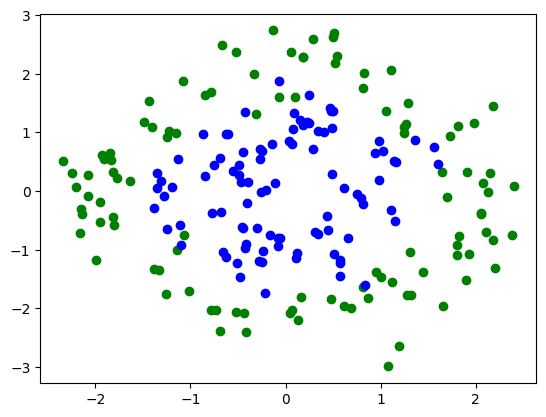

In [23]:
positives=X[np.where(y==1)] #collecting the inputs with positive labels 
negatives=X[np.where(y==0)] #inputs with negative labels 
plt.scatter(positives[:,0],positives[:,1],color="green")  #scatter plot of the positive labeled data
plt.scatter(negatives[:,0],negatives[:,1],color="blue")   #scatter plot of the negative labelled data
plt.show()

In [24]:
lr=LogisticRegression()

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)   #don't train on the test set 
lr.fit(X_train,y_train)  

LogisticRegression()

In [26]:
y_pred=lr.predict(X_test) #predictions. Note that we have 2d data so no need to reshape 

In [27]:
accuracy_score(y_pred,y_test) #checking the accuracy. Not so good, right? 

0.425

It turns out the accuracy is not so good, and that was to be expected. Indeed, it is clear from the scatter plot that the data is not linearly separable!  In other words, the approximation error is very high because we cannot represent the ground truth... 

How about applying a polynomial transform before running the model? This should increase representation power! If we do that, the scores take the form sigmoid(polynomial), so it means that the cutoff line between positive and negative labels (the line where the scores are 0) will be a contour of a polynomial. This could represent ellipses such as $5x^2+1.2y^2=2$ for instance.

In [28]:
from sklearn.preprocessing import PolynomialFeatures
XX_train,XX_test=PolynomialFeatures(2).fit_transform(X_train),PolynomialFeatures(2).fit_transform(X_test) 
#making polynomial representations
lr.fit(XX_train,y_train) #fitting the model 
y_pred=lr.predict(XX_test)


In [29]:
accuracy_score(y_pred,y_test)

0.975

We see that the accuracy is much better! This is because we don't have a huge approximation error anymore. On the other hand, there is still some error, which could be either from the bayes error or from estimation error as the dataset isn't that big. 

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/1w/jldpjws132g2_8q00vy2f8h80000gn/T/ipykernel_92934/1583090048.py:30: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')


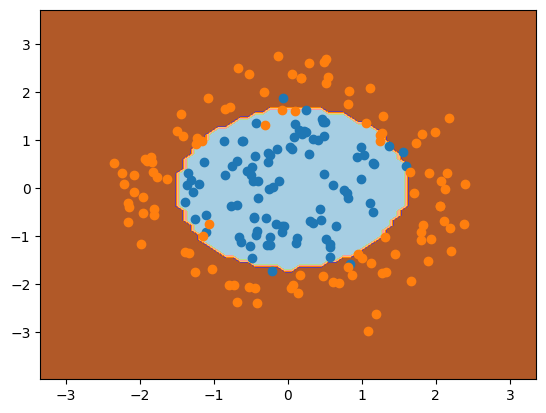

In [30]:
import sklearn


min1, max1 = X[:, 0].min()-1, X[:, 0].max()+1
min2, max2 = X[:, 1].min()-1, X[:, 1].max()+1
# define the x and y scale
x1grid = np.arange(min1, max1, 0.1)
x2grid = np.arange(min2, max2, 0.1)
# create all of the lines and rows of the grid
xx, yy = np.meshgrid(x1grid, x2grid)
# flatten each grid to a vector
r1, r2 = xx.flatten(), yy.flatten()
r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))
# horizontal stack vectors to create x1,x2 input for the model
grid = np.hstack((r1,r2))
# extend grid via polynomial transform 
grid=PolynomialFeatures(2).fit_transform(grid)

# make predictions for the grid
yhat = lr.predict(grid)
# reshape the predictions back into a grid
zz = yhat.reshape(xx.shape)
# plot the grid of x, y and z values as a surface
plt.contourf(xx, yy, zz, cmap='Paired')
# create scatter plot for samples from each class
for class_value in range(2):
    # get row indexes for samples with this class
    row_ix = np.where(y == class_value)
    # create scatter of these samples
    plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')

Now, let's try a more specific method: looking at the data, it really looks like the distance to the center is the main variable. Let's just transform the data to keep this only:

In [31]:
from sklearn.preprocessing import PolynomialFeatures
XX_train,XX_test=np.linalg.norm(X_train,axis=1),np.linalg.norm(X_test,axis=1) #computing the distances to the centre for all the data
lr.fit(XX_train.reshape(-1,1),y_train)
y_pred=lr.predict(XX_test.reshape(-1,1))


In [32]:
accuracy_score(y_pred,y_test) #Pretty good too. 

0.95

The accuracy is even better in this case because we chose the right function class spot on. This was a high risk strategy but it paid off because the data was generated by a human: we picked a smaller function class, so the estimation error is smaller. At the same time, the ground truth is actually still contained in this smaller function class, so we didn't loose anything in terms of approximation error either, hence improved performance. 

#### Going further with underfitting and overfitting. 

Let's run the polynomial version again, but with an arbitrary value of the degree

In [33]:
from sklearn.preprocessing import PolynomialFeatures

d=20
X=np.load("chips.npz")["X"] #loading inputs
y=np.load("chips.npz")["y"] #loading outputs. X,y are now numpy arrays loaded from the binary .npz file. 
lr=LogisticRegression()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)   #don't train on the test set 


XX_train,XX_test=PolynomialFeatures(d).fit_transform(X_train),PolynomialFeatures(d).fit_transform(X_test) 
#making polynomial representations
lr.fit(XX_train,y_train) #fitting the model 
y_pred=lr.predict(XX_test)

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/1w/jldpjws132g2_8q00vy2f8h80000gn/T/ipykernel_92934/1201912110.py:30: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')


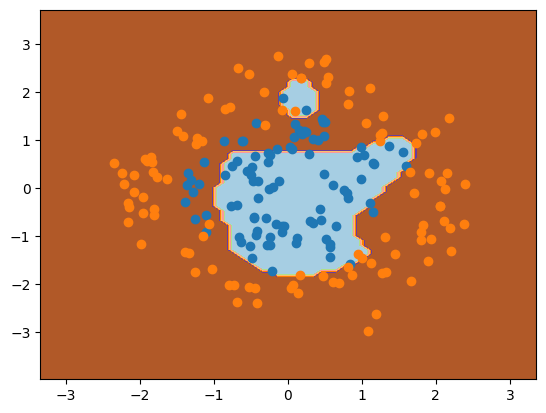

In [34]:
import sklearn


min1, max1 = X[:, 0].min()-1, X[:, 0].max()+1
min2, max2 = X[:, 1].min()-1, X[:, 1].max()+1
# define the x and y scale
x1grid = np.arange(min1, max1, 0.1)
x2grid = np.arange(min2, max2, 0.1)
# create all of the lines and rows of the grid
xx, yy = np.meshgrid(x1grid, x2grid)
# flatten each grid to a vector
r1, r2 = xx.flatten(), yy.flatten()
r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))
# horizontal stack vectors to create x1,x2 input for the model
grid = np.hstack((r1,r2))
# extend grid via polynomial transform 
grid=PolynomialFeatures(d).fit_transform(grid)

# make predictions for the grid
yhat = lr.predict(grid)
# reshape the predictions back into a grid
zz = yhat.reshape(xx.shape)
# plot the grid of x, y and z values as a surface
plt.contourf(xx, yy, zz, cmap='Paired')
# create scatter plot for samples from each class
for class_value in range(2):
    # get row indexes for samples with this class
    row_ix = np.where(y == class_value)
    # create scatter of these samples
    plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')

In [35]:
print(accuracy_score(y_pred,y_test)) 
lr_probs = lr.predict_proba(XX_test)
A=np.array(y_test)
B=[1-A,A]
y_test_dummy=np.array(B).transpose()
print(roc_auc_score(y_test_dummy, lr_probs,multi_class="ovr"))

0.8
0.9299999999999999


/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


We see a significant decrease in performance due to overfitting!

#### Exercise 4 : Now let's try this with the larger dataset

You can find the dataset in a file called "chips_much.npz".  Plot the scatter plot and try the same two methods as above. Note the dataset was generated from the same distribution as above, it just has more data. 

#### Solution: 

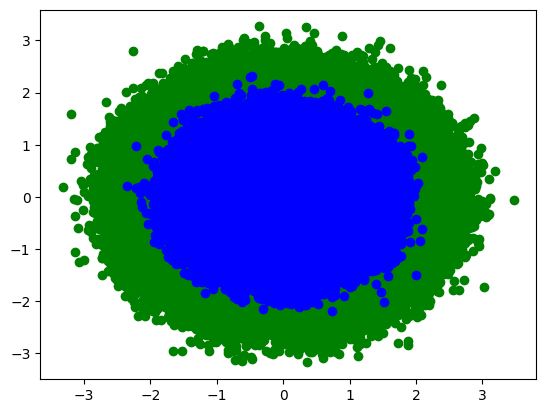

In [38]:
X2=np.load("chips_much.npz")["X"] #loading data 
y2=np.load("chips_much.npz")["y"]
positives=X2[np.where(y2==1)] #collecting data with positive labels 
negatives=X2[np.where(y2==0)]
plt.scatter(positives[:,0],positives[:,1],color="green")
plt.scatter(negatives[:,0],negatives[:,1],color="blue")
plt.show()


In [37]:

X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y2,test_size=0.2) 
X2_train,X2_test=np.linalg.norm(X2_train,axis=1),np.linalg.norm(X2_test,axis=1) #norm transform based on amazing intuition
lr.fit(X2_train.reshape(-1,1),y2_train)
y_pred=lr.predict(X2_test.reshape(-1,1)) #1d data here, don't forget to reshape... 
accuracy_score(y_pred,y2_test)

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


0.92025

In [ ]:
X2=np.load("chips_much.npz")["X"]
y2=np.load("chips_much.npz")["y"]
from sklearn.preprocessing import PolynomialFeatures   #polynomial transforms
lr=LogisticRegression()
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y2,test_size=0.2) 
X2_train,X2_test=PolynomialFeatures(2).fit_transform(X2_train),PolynomialFeatures(2).fit_transform(X2_test)  #applying poly trans.
lr.fit(X2_train,y2_train)
y_pred=lr.predict(X2_test) #we have data of dimension 1+2+4 so definitely no need to reshape. 
accuracy_score(y_pred,y2_test)